# (3) Linear vs non-linear P(k) against data

**Question:** How do the *linear* P(k)
([`pyccl.emulators.baccoemu_linear_pk.BaccoemuLinear`](https://ccl.readthedocs.io/en/latest/api/pyccl.emulators.baccoemu_linear_pk.html))
and *non-linear* P(k) (MiraTitan-IV gravity-only; CosmoHydro `Pk_GO` and
`Pk_hydro = Pk-ratio × Pk_GO`) compare against observational data?

Observational data live in `../data_observational/` and are loaded through
`load_obs_data.py` (the only helper `.py`, reserved for data loading):

- **Linear (z = 0):** CMB-derived P(k) (WMAP+ACT, Hlozek+12), SDSS DR7 LRG (Reid+10),
  and eBOSS DR14 Lyα (Chabanier+19) — together spanning k ≈ 0.005–3.7 h Mpc⁻¹.
- **Non-linear:** the KiDS-Legacy deprojected matter power spectrum
  Pm(k, z) (Broxterman+25, A&A 703 L3) in tomographic bins z_fid = 0.15, 0.45 —
  a direct *nonlinear total-matter* measurement, compared in its own section below.
- **Drop-in user data**: any `[k, P, err]` text file placed in
  `../data_observational/user_pk/` is picked up automatically
  (k in h Mpc⁻¹, P in (h⁻¹Mpc)³ at z = 0; name it `*_nl.txt` for nonlinear).

(The digitized `PowerSpectraObservationData.{csv,xlsx}` in `RealData/` are not used:
their plot-digitizer axes were never calibrated, and the calibrated files above cover
the same surveys.)

Cosmology is fixed to Frontier-E (`../fixed_parameters.txt`).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import numpy as np
import matplotlib.pyplot as plt

import cosmohydro_emu as ce
import pyccl
from pyccl.emulators.cosmicemu_pk import CosmicemuMTIVPk
from pyccl.emulators.baccoemu_linear_pk import BaccoemuLinear

sys.path.insert(0, '../data_observational')
import load_obs_data

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params()
h = FP['h']
Ob = FP['Omega_b_h2'] / h**2
cosmo = pyccl.Cosmology(Omega_c=FP['Omega_m'] - Ob, Omega_b=Ob, h=h,
                        sigma8=FP['sigma_8'], n_s=FP['n_s'],
                        transfer_function='bbks')  # emulators use params only

# Emulated spectra (all converted to k [h/Mpc], P [(Mpc/h)^3])
k_th = np.logspace(np.log10(0.008), np.log10(8.0), 400)
pk_lin = BaccoemuLinear().get_pk2d(cosmo)(k_th * h, 1.0, cosmo) * h**3
pk_mt = CosmicemuMTIVPk('tot').get_pk2d(cosmo)(k_th * h, 1.0, cosmo) * h**3

P5 = [FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin'], FP['epsilon_kin']]
p_cosmo = [FP['omega_m'], FP['sigma_8']]
k_ch, _ = ce.get_x_grid('Pk_GO')
k_ch = np.asarray(k_ch)
pk_go, _ = ce.load_emulator('Pk_GO').predict(p_cosmo, z=0.0)
ratio, _ = ce.load_emulator('Pk-ratio').predict(P5 + p_cosmo, z=0.0)
pk_hydro = ratio * pk_go

# Observational data
obs = load_obs_data.load_all_linear(h=h)
for d in obs:
    print(f"loaded: {d['label']}  ({len(d['k'])} points, kind={d['kind']})")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Arico et al. (2021)...
Baryonic Emulator Arico et al. (2025) loaded in memory.
loaded: eBOSS DR14 Ly$\alpha$ (Chabanier+19)  (19 points, kind=linear)
loaded: SDSS DR7 LRG (Reid+10)  (45 points, kind=linear)
loaded: CMB: WMAP+ACT (Hlozek+12)  (8 points, kind=linear)


## P(k) at z = 0: linear vs non-linear vs data

Note the k-ranges: bacco linear is valid over the whole plotted range *as linear theory*;
MiraTitan-IV is a nonlinear gravity-only emulator (k ≲ 5 h Mpc⁻¹);
CosmoHydro spectra live on k ∈ [0.016, 8] h Mpc⁻¹.

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Arico et al. (2021)...
Baryonic Emulator Arico et al. (2025) loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Arico et al. (2021)...
Baryonic Emulator Arico et al. (2025) loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryo

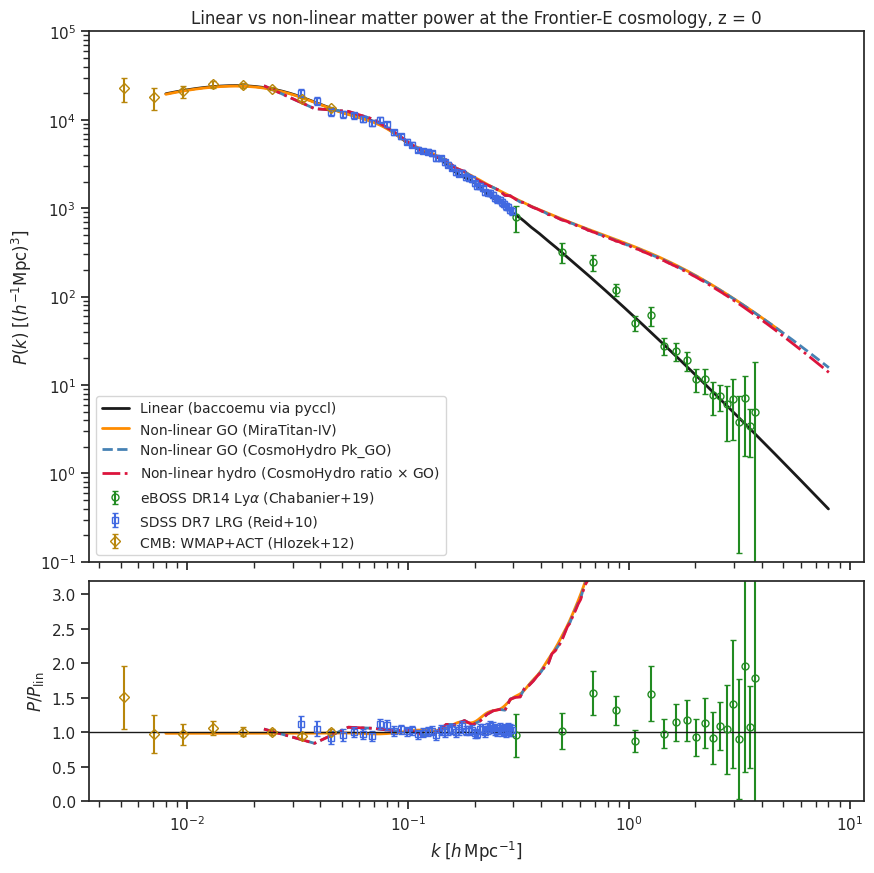

In [3]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                              gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.05})

ax.loglog(k_th, pk_lin, color='k', lw=2, label='Linear (baccoemu via pyccl)')
ax.loglog(k_th[k_th <= 5], pk_mt[k_th <= 5], color='darkorange', lw=2,
          label='Non-linear GO (MiraTitan-IV)')
ax.loglog(k_ch, pk_go, color='steelblue', lw=2, ls='--', label='Non-linear GO (CosmoHydro Pk_GO)')
ax.loglog(k_ch, pk_hydro, color='crimson', lw=2, ls='-.',
          label=r'Non-linear hydro (CosmoHydro ratio $\times$ GO)')

markers = ['o', 's', 'D', '^', 'v']
obs_colors = ['forestgreen', 'royalblue', 'darkgoldenrod', 'teal', 'purple']
for d, mk, c in zip(obs, markers, obs_colors):
    ax.errorbar(d['k'], d['P'], yerr=d['err'], fmt=mk, ms=5, capsize=2,
                mfc='none', color=c, label=d['label'])

ax.set_ylabel(r'$P(k)\;[(h^{-1}{\rm Mpc})^3]$')
ax.set_title('Linear vs non-linear matter power at the Frontier-E cosmology, z = 0')
ax.legend(fontsize=10, loc='lower left')
ax.set_ylim(1e-1, 1e5)

# ratios to linear theory
pk_lin_ch = BaccoemuLinear().get_pk2d(cosmo)(k_ch * h, 1.0, cosmo) * h**3
axr.semilogx(k_th[k_th <= 5], (pk_mt / pk_lin)[k_th <= 5], color='darkorange', lw=2)
axr.semilogx(k_ch, pk_go / pk_lin_ch, color='steelblue', lw=2, ls='--')
axr.semilogx(k_ch, pk_hydro / pk_lin_ch, color='crimson', lw=2, ls='-.')
for d, mk, c in zip(obs, markers, obs_colors):
    pk_lin_d = BaccoemuLinear().get_pk2d(cosmo)(np.asarray(d['k']) * h, 1.0, cosmo) * h**3
    yerr = d['err'] / pk_lin_d if d['err'] is not None else None
    axr.errorbar(d['k'], d['P'] / pk_lin_d, yerr=yerr, fmt=mk, ms=5, capsize=2,
                 mfc='none', color=c)
axr.axhline(1, color='k', lw=1)
axr.set_ylim(0, 3.2)
axr.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
axr.set_ylabel(r'$P / P_{\rm lin}$')
plt.tight_layout(); plt.show()

## Non-linear data: KiDS-Legacy deprojected Pm(k, z)

Broxterman et al. (2025) deproject KiDS-Legacy cosmic shear into the matter power
spectrum Pm(k, z) = f_δ × P_dmo at fiducial redshifts z_fid = 0.15 and 0.45 (`nz3`
binning; the z_fid = 1.3 bin is very weakly constrained and omitted, as in the
Inference_cosmo pipeline). This is a direct **nonlinear total-matter** measurement, so
the natural comparisons are the emulated hydro P(k, z_fid), the gravity-only spectra,
and — to show where linear theory fails — the bacco linear P(k).

The linear curve is drawn on the same k-grid (0.008–8 h Mpc⁻¹) as the z = 0 figure
above; its only difference from that plot is the growth factor D²(z_fid)
(≈ 0.86 at z = 0.15, ≈ 0.66 at z = 0.45), which lowers the whole curve.

KiDS-Legacy $P_m$ (nz3): 40 points, k = 0.010 - 19.8 h/Mpc  (Broxterman et al. 2025, A&A 703, L3)
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Arico et al. (2021)...
Baryonic Emulator Arico et al. (2025) loaded in memory.


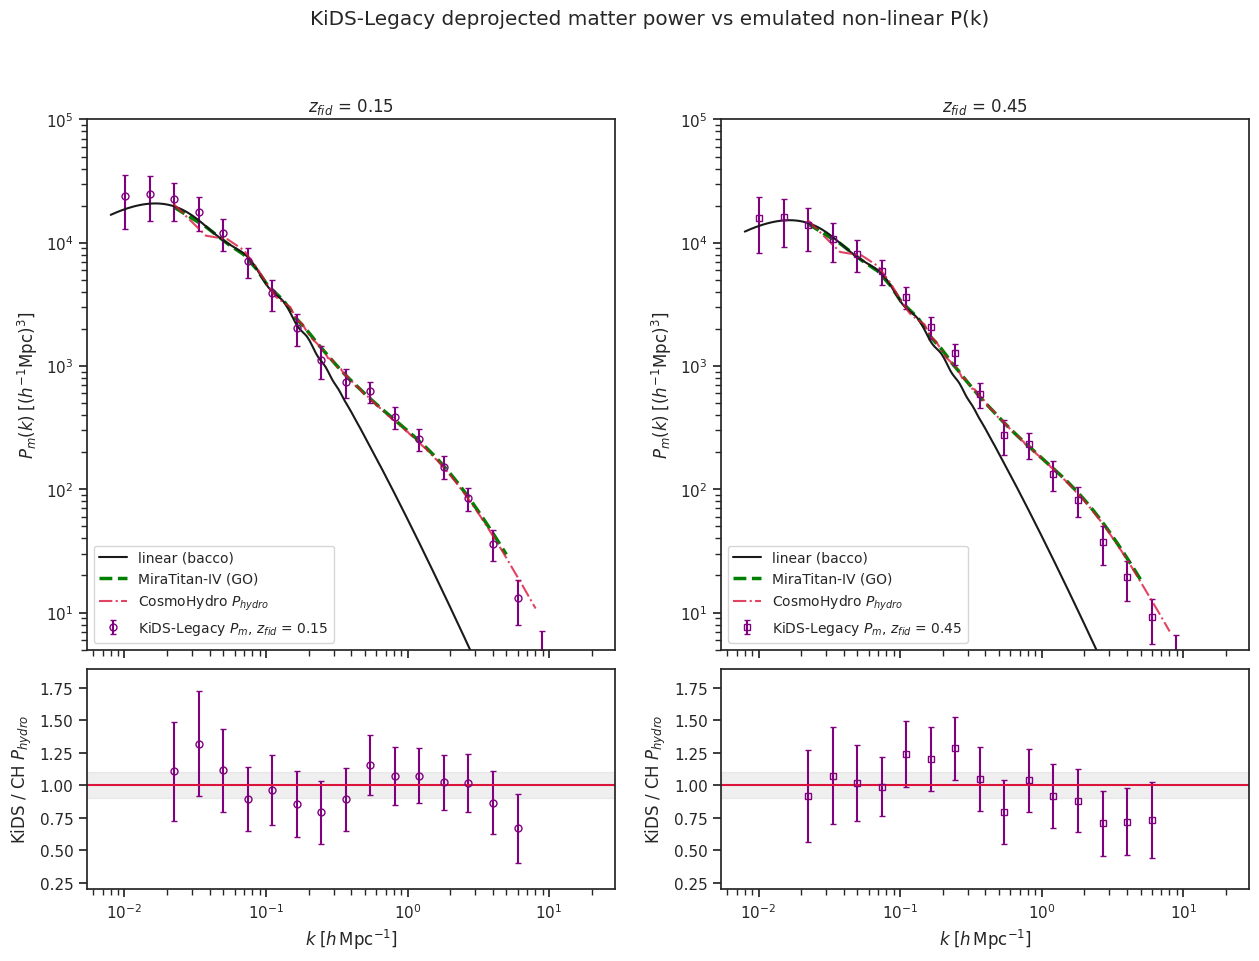

In [14]:
kids = load_obs_data.load_kids_legacy(nz='nz3', z_bins=[0.15, 0.45])
print(f"{kids['label']}: {len(kids['k'])} points, k = {kids['k'].min():.3f} - "
      f"{kids['k'].max():.1f} h/Mpc  ({kids['ref']})")

emu_go = ce.load_emulator('Pk_GO')
emu_ratio = ce.load_emulator('Pk-ratio')
bacco = BaccoemuLinear().get_pk2d(cosmo)
mt2d = CosmicemuMTIVPk('tot').get_pk2d(cosmo)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.05})

for j, (zf, mk) in enumerate(zip([0.15, 0.45], ['o', 's'])):
    ax, axr = axes[0, j], axes[1, j]
    sel = kids['z'] == zf
    kk, pp, ee = kids['k'][sel], kids['P'][sel], kids['err'][sel]

    a = 1.0 / (1.0 + zf)
    # linear P(k) on the same full k-grid (k_th, 0.008-8 h/Mpc) as the z = 0
    # figure above -- only the growth factor differs between the two plots
    p_lin = bacco(k_th * h, a, cosmo) * h**3
    p_mt = mt2d(k_ch * h, a, cosmo) * h**3
    p_go, _ = emu_go.predict(p_cosmo, z=zf)
    r_emu, _ = emu_ratio.predict(P5 + p_cosmo, z=zf)
    p_hyd = r_emu * p_go

    ax.errorbar(kk, pp, yerr=ee, fmt=mk, ms=5, capsize=2, mfc='none', color='purple',
                label=f'KiDS-Legacy $P_m$, $z_{{fid}}$ = {zf}')
    ax.loglog(k_th, p_lin, color='k', lw=1.5, label='linear (bacco)')
    mmt = k_ch <= 5
    ax.loglog(k_ch[mmt], p_mt[mmt], color='green', lw=2.5, ls='--', label='MiraTitan-IV (GO)', zorder=1)
    ax.loglog(k_ch, p_hyd, color='crimson', lw=1.5, ls='-.', label=r'CosmoHydro $P_{hydro}$', zorder=2, alpha=0.8)
    ax.set_ylim(5, 1e5)
    ax.set_title(f'$z_{{fid}}$ = {zf}')
    ax.set_ylabel(r'$P_m(k)\;[(h^{-1}{\rm Mpc})^3]$')
    ax.legend(fontsize=10, loc='lower left')

    # ratio to the emulated hydro prediction
    lo, hi = k_ch.min(), k_ch.max()
    ms = (kk >= lo) & (kk <= hi)
    p_hyd_i = np.interp(np.log10(kk[ms]), np.log10(k_ch), p_hyd)
    axr.errorbar(kk[ms], pp[ms] / p_hyd_i, yerr=ee[ms] / p_hyd_i, fmt=mk, ms=5,
                 capsize=2, mfc='none', color='purple')
    axr.axhline(1, color='crimson', lw=1.5)
    axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_xscale('log'); axr.set_ylim(0.2, 1.9)
    axr.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
    axr.set_ylabel(r'KiDS / CH $P_{hydro}$')

plt.suptitle('KiDS-Legacy deprojected matter power vs emulated non-linear P(k)', y=0.99)
plt.tight_layout(); plt.show()

## Where does linear theory break, and where do baryons matter?

Two characteristic scales, quantified below:
1. **Non-linear scale**: k where the MiraTitan-IV nonlinear spectrum departs from
   linear theory by more than 5% / 20%.
2. **Baryon scale**: k where the emulated hydro suppression `Pk-ratio` departs
   from unity by more than 1% / 5%.

In [5]:
nl_dev = np.abs(pk_mt / pk_lin - 1)
for thresh in [0.05, 0.20]:
    k_nl = k_th[(k_th < 5) & (k_th > 0.05) & (nl_dev > thresh)]
    print(f'non-linear deviation > {thresh:.0%} for k > {k_nl.min():.3f} h/Mpc' if len(k_nl)
          else f'never exceeds {thresh:.0%}')

bar_dev = np.abs(ratio - 1)
for thresh in [0.01, 0.05]:
    k_b = k_ch[bar_dev > thresh]
    print(f'baryonic |P_hydro/P_grav - 1| > {thresh:.0%} for k > {k_b.min():.3f} h/Mpc' if len(k_b)
          else f'baryonic suppression never exceeds {thresh:.0%}')

non-linear deviation > 5% for k > 0.147 h/Mpc
non-linear deviation > 20% for k > 0.211 h/Mpc
baryonic |P_hydro/P_grav - 1| > 1% for k > 0.887 h/Mpc
baryonic |P_hydro/P_grav - 1| > 5% for k > 3.573 h/Mpc


## Notes

- The **linear datasets** are all quoted as the equivalent *z = 0 linear* P(k) by their
  authors; they should (and do) track the linear curve, not the nonlinear ones. The Lyα
  file stores k in Mpc⁻¹ and P in (h⁻¹Mpc)³, the Reid+10 and WMAP+ACT files are already
  in (k [h/Mpc], P [(Mpc/h)³]) — all three conventions verified numerically against
  linear theory in/for `load_obs_data.py` (agreement at the ~5% level).
- The **KiDS-Legacy Pm** carries the measurement caveats of Broxterman+25: the lensing
  kernel assumes a fixed flat ΛCDM with Ωm = 0.305 ± 0.012, and NLA-M intrinsic
  alignments. Its preference for suppressed power at k ≳ 1 h Mpc⁻¹ relative to
  gravity-only predictions is the "strong baryonic feedback" signal discussed in that
  paper — compare with the emulated `Pk-ratio` suppression.
- The **full mpk compilation** (DES and further CMB/SDSS points of Chabanier+2019)
  requires running their Julia+CAMB pipeline
  (see `../data_observational/RealData/mpk_compilation/README.md`); the digitized
  spreadsheet in `RealData/` cannot substitute for it (uncalibrated axes).
- The comparison between `Pk_hydro` and the gravity-only curves shows baryonic feedback
  suppressing power by ~10% around k ≈ 5-8 h Mpc⁻¹ at this feedback setting — small
  compared to the nonlinear boost, but far larger than survey statistical errors at
  those scales, which is the reason for emulating it.